# House Price Prediction

### Import the necessary libraries and load the dataset.

In [100]:
# Core imports for data handling and visualization
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Modeling and evaluation imports
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
# Statistical helpers used later for diagnostics
import statsmodels.api as sm
import statsmodels.stats.api as sms
import scipy.stats as stats

In [101]:
# Load datasets - provide full paths relative to the notebook's working directory
train_df = pd.read_csv('Datasets/train_(2)_(1)_(1).csv')
test_df = pd.read_csv('Datasets/test_(2)_(1)_(1).csv')
avg_rent = pd.read_csv('Datasets/avg_rent_(1)_(1)_(1).csv')
# auxiliary dataset used to map location -> distance from city centre
city_dist = pd.read_csv('Datasets/dist_from_city_centre_(1).csv')

In [102]:
train_df.head()

,ID,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [103]:
avg_rent.head()

,location,avg_2bhk_rent
0,Krishnarajapura,11954
1,Sarjapur,45000
2,Whitefield Hope Farm Junction,26370
3,Devanahalli,17302
4,Whitefield,14981


In [104]:
test_df.head()

,ID,area_type,availability,location,size,society,total_sqft,bath,balcony
0,0,Super built-up Area,Ready To Move,Chamrajpet,2 BHK,NaN,650,1.0,1.0
1,1,Super built-up Area,Ready To Move,7th Phase JP Nagar,3 BHK,SrncyRe,1370,2.0,1.0
2,2,Super built-up Area,Ready To Move,Whitefield,3 BHK,AjhalNa,1725,3.0,2.0
3,3,Built-up Area,Ready To Move,Jalahalli,2 BHK,NaN,1000,2.0,0.0
4,4,Plot Area,Ready To Move,TC Palaya,1 Bedroom,NaN,1350,1.0,0.0


In [105]:
train_df.shape

(10656, 10)

In [106]:
avg_rent.shape

(157, 2)

In [107]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10656 entries, 0 to 10655
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   ID            10656 non-null  int64  
 1   area_type     10656 non-null  object 
 2   availability  10656 non-null  object 
 3   location      10655 non-null  object 
 4   size          10642 non-null  object 
 5   society       6228 non-null   object 
 6   total_sqft    10656 non-null  object 
 7   bath          10591 non-null  float64
 8   balcony       10152 non-null  float64
 9   price         10656 non-null  float64
dtypes: float64(3), int64(1), object(6)
memory usage: 832.6+ KB


##### We can observe that more features are object and some of the features have missing values.

In [108]:
train_df.describe()

,ID,bath,balcony,price
count,10656.000000,10591.000000,10152.000000,10656.000000
mean,5327.500000,2.690586,1.581757,112.214256
std,3076.266568,1.352403,0.821357,142.231967
min,0.000000,1.000000,0.000000,8.000000
25%,2663.750000,2.000000,1.000000,50.000000
50%,5327.500000,2.000000,2.000000,72.000000
75%,7991.250000,3.000000,2.000000,120.000000
max,10655.000000,40.000000,3.000000,2700.000000


In [109]:
train_df.isna().sum()

ID                 0
area_type          0
availability       0
location           1
size              14
society         4428
total_sqft         0
bath              65
balcony          504
price              0
dtype: int64

In [110]:
test_df.isna().sum()

ID                 0
area_type          0
availability       0
location           0
size               2
society         1074
total_sqft         0
bath               8
balcony          105
dtype: int64

##### Will take a copy of the dataframe to avoid any changes to the original dataframe.

In [111]:
train_df_copy = train_df.copy()

### Data Cleaning and Preprocessing

In [112]:
train_df_copy['society'].unique()

array(['Coomee ', 'Theanmp', nan, ..., 'ArariGo', 'Vicony ', 'Srhemay'],
      dtype=object)

In [113]:
train_df_copy['society'].nunique()

2364

##### Will drop the 'ID' column as it does not contribute to the prediction. 

##### Also 'society' column has a lot of unique values which may not contribute to the prediction. Hence dropping that too.

In [114]:
train_df_copy['area_type'].value_counts()

area_type
Super built-up  Area    7009
Built-up  Area          1927
Plot  Area              1651
Carpet  Area              69
Name: count, dtype: int64

In [115]:
train_df_copy['availability'].unique()

array(['19-Dec', 'Ready To Move', '18-May', '18-Feb', '18-Nov', '20-Dec',
       '17-Oct', '21-Dec', '19-Sep', '20-Sep', '18-Mar', '20-Feb',
       '18-Apr', '20-Aug', '18-Oct', '19-Mar', '17-Sep', '18-Dec',
       '17-Aug', '19-Apr', '18-Jun', '22-Dec', '22-Jan', '18-Aug',
       '19-Jan', '17-Jul', '18-Jul', '21-Jun', '20-May', '19-Aug',
       '18-Sep', '17-May', '17-Jun', '21-May', '18-Jan', '20-Mar',
       '17-Dec', '16-Mar', '19-Jun', '22-Jun', '19-Jul', '21-Feb',
       'Immediate Possession', '19-May', '17-Nov', '20-Oct', '20-Jun',
       '19-Feb', '21-Oct', '21-Jan', '17-Mar', '17-Apr', '22-May',
       '19-Oct', '21-Jul', '21-Nov', '21-Mar', '16-Dec', '22-Mar',
       '20-Jan', '21-Sep', '21-Aug', '14-Nov', '19-Nov', '15-Nov',
       '16-Jul', '15-Jun', '17-Feb', '20-Nov', '20-Jul', '16-Sep',
       '15-Oct', '15-Dec', '16-Oct', '22-Nov', '15-Aug', '17-Jan',
       '16-Nov', '20-Apr'], dtype=object)

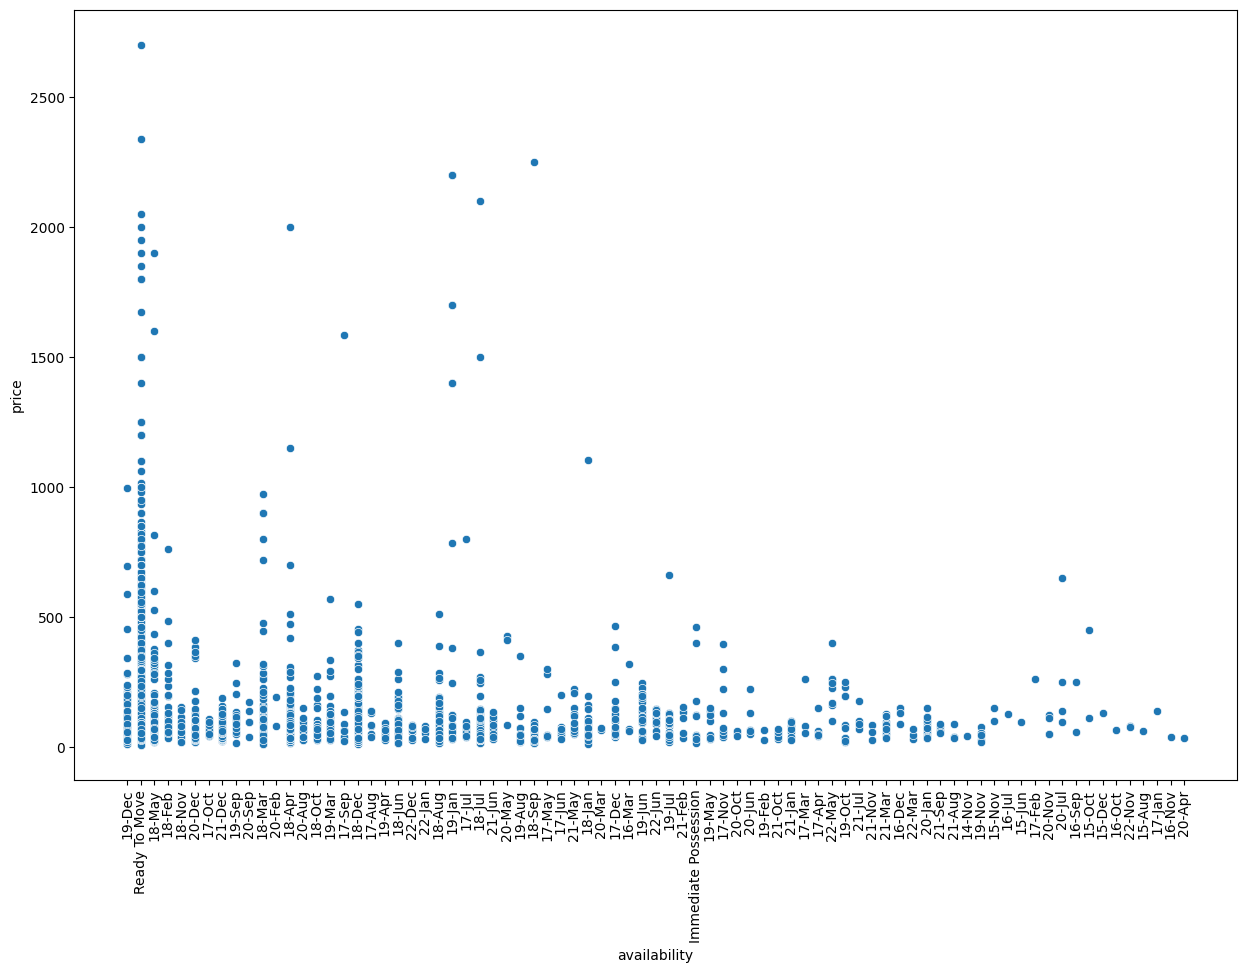

In [116]:
plt.figure(figsize=(15,10))
sns.scatterplot(x='availability', y='price', data=train_df_copy)
plt.xticks(rotation=90)
plt.show()

##### Will remove this 'availability' features 

In [117]:
train_df_copy['location'].unique().tolist()

['Electronic City Phase II',
 'Chikka Tirupathi',
 'Uttarahalli',
 'Lingadheeranahalli',
 'Kothanur',
 'Whitefield',
 'Old Airport Road',
 'Rajaji Nagar',
 'Marathahalli',
 'Gandhi Bazar',
 '7th Phase JP Nagar',
 'Gottigere',
 'Sarjapur',
 'Mysore Road',
 'Bisuvanahalli',
 'Raja Rajeshwari Nagar',
 'Ramakrishnappa Layout',
 'Manayata Tech Park',
 'Kengeri',
 'Binny Pete',
 'Thanisandra',
 'Bellandur',
 ' Thanisandra',
 'Mangammanapalya',
 'Electronic City',
 'Ramagondanahalli',
 'Yelahanka',
 'Hebbal',
 'Kasturi Nagar',
 'Kanakpura Road',
 'Electronics City Phase 1',
 'Kundalahalli',
 'Chikkalasandra',
 'Murugeshpalya',
 'Sarjapur  Road',
 'Ganga Nagar',
 'HSR Layout',
 'Doddathoguru',
 'KR Puram',
 'Himagiri Meadows',
 'Adarsh Nagar',
 'Bhoganhalli',
 'Lakshminarayana Pura',
 'Begur Road',
 'Devanahalli',
 'Govindaraja Nagar Ward',
 'Tharabanahalli',
 'Varthur',
 'Bommanahalli',
 'Gunjur',
 'Devarachikkanahalli',
 'Double Road',
 'Hegde Nagar',
 'Haralur Road',
 'Hennur Road',
 'Kotha

In [118]:
train_df_copy['location'].nunique()

1197

##### Here some values are having spelling issue which we will correct it.

In [119]:
train_df_copy['size'].unique()

array(['2 BHK', '4 Bedroom', '3 BHK', '4 BHK', '6 Bedroom', '3 Bedroom',
       '1 BHK', '1 RK', '1 Bedroom', '8 Bedroom', '2 Bedroom',
       '7 Bedroom', '5 BHK', '7 BHK', '6 BHK', '5 Bedroom', '11 BHK',
       '9 BHK', nan, '9 Bedroom', '27 BHK', '10 Bedroom', '11 Bedroom',
       '10 BHK', '19 BHK', '16 BHK', '43 Bedroom', '14 BHK', '8 BHK',
       '12 Bedroom', '13 BHK'], dtype=object)

##### Will make 1 RK as 0 and will strip the value to remove string from the column, and none values to Mode.

In [120]:
train_df_copy['total_sqft']

0        1056
1        2600
2        1440
3        1521
4        1200
         ... 
10651    1200
10652    1260
10653    1092
10654     827
10655    1357
Name: total_sqft, Length: 10656, dtype: object

##### 'total_sqft' column is in object. Will check if there are any non-numeric values.

In [121]:
def check_float(x):
    try:
        float(x)
    except:
        return False
    return True

In [122]:
train_df_copy[~train_df_copy['total_sqft'].apply(lambda x : check_float(x))]['total_sqft'].unique()

array(['2100 - 2850', '3010 - 3410', '2957 - 3450', '3067 - 8156',
       '1042 - 1105', '1145 - 1340', '1015 - 1540', '1520 - 1740',
       '34.46Sq. Meter', '1195 - 1440', '1200 - 2400', '4125Perch',
       '1120 - 1145', '4400 - 6640', '3090 - 5002', '4400 - 6800',
       '1160 - 1195', '1000Sq. Meter', '4000 - 5249', '1115 - 1130',
       '1100Sq. Yards', '520 - 645', '1000 - 1285', '3606 - 5091',
       '650 - 665', '633 - 666', '5.31Acres', '30Acres', '1445 - 1455',
       '884 - 1116', '850 - 1093', '1440 - 1884', '716Sq. Meter',
       '547.34 - 827.31', '580 - 650', '3425 - 3435', '1804 - 2273',
       '3630 - 3800', '660 - 670', '1500Sq. Meter', '620 - 933',
       '142.61Sq. Meter', '2695 - 2940', '2000 - 5634', '1574Sq. Yards',
       '3450 - 3472', '1250 - 1305', '670 - 980', '1005.03 - 1252.49',
       '1004 - 1204', '361.33Sq. Yards', '645 - 936', '2710 - 3360',
       '2249.81 - 4112.19', '3436 - 3643', '2830 - 2882', '596 - 804',
       '1255 - 1863', '1300 - 1405', '1

##### We can see that many values are having ranges and some values are having units. We will take range values as average of the range, and unit values will be None. 

In [123]:
train_df_copy['bath'].value_counts()

bath
2.0     5530
3.0     2608
4.0      991
1.0      639
5.0      411
6.0      216
7.0       86
8.0       48
9.0       35
10.0      11
12.0       7
16.0       2
11.0       2
27.0       1
14.0       1
40.0       1
15.0       1
13.0       1
Name: count, dtype: int64

Now we will do all above steps in function for better reusability.

In [124]:
test_df.isna().sum()

ID                 0
area_type          0
availability       0
location           0
size               2
society         1074
total_sqft         0
bath               8
balcony          105
dtype: int64

In [125]:
train_df.columns

Index(['ID', 'area_type', 'availability', 'location', 'size', 'society',
       'total_sqft', 'bath', 'balcony', 'price'],
      dtype='object')

In [126]:
del_col = ['ID', 'availability', 'society', 'balcony']

In [127]:
def get_size_value(x):
    if pd.isna(x):
        return x
    return x.split()[0]

In [128]:
def get_sq_ft(x):
    if check_float(x):
        return x
    else:
        val = x.split(' - ')
        if len(val) == 2:
            return (float(val[0])+float(val[1]))/2
        return None

In [129]:
def check_insance(x):
    if isinstance(x, list):
        return any
    elif isinstance(x, tuple):
        return all


In [130]:
def loc_clean(x):
    x = x.lower()
    x = re.sub(r'[, !&. /-]', '', x)
    return x

In [131]:
loc = {
    '1st Block HRBR Layout' : ('hrbr', '1stblock'),
    '2nd Block Hrbr Layout' : ('hrbr', '2ndblock'),
    '3rd Block Hrbr Layout' : ('hrbr', '3rdblock'),
    'HRBR Layout' : ('hrbr',),
    'Vijayanagar' : ['vijayanagar', 'vijaynagar'],
    '1st Block Jayanagar' : ('jayanagar', '1stblock'),
    '2nd Block Jayanagar' : ('jayanagar', '2ndblock'),
    '4th T block Jayanagar' : ('jayanagar', '4thblock'),
    '7th Block Jayanagar' : ('jayanagar', '7thblock'),
    '9th Block Jayanagar' : ('jayanagar', '9thblock'),
    'Jayanagar' : ('jayanagar',),
    '1st Block Koramangala' : ('koramangala', '1stblock'),
    '4th Block Koramangala' : ('koramangala', '4thblock'),
    '6th block Koramangala' : ('koramangala', '6thblock'),
    '8th block Koramangala' : ('koramangala', '8thblock'),
    'Koramangala' : ('koramangala',),
    '1st Phase JP Nagar' : ('jpnagar', '1stphase'),
    '2nd Phase JP Nagar' : ('jpnagar', '2ndphase'),
    '4th Phase JP Nagar' : ('jpnagar', '4thphase'),
    '5th Phase JP Nagar' : ('jpnagar', '5thphase'),
    '6th Phase JP Nagar' : ('jpnagar', '6thphase'),
    '7th Phase JP Nagar' : ('jpnagar', '7thphase'),
    '8th Phase JP Nagar' : ('jpnagar', '8thphase'),
    '9th Phase JP Nagar' : ('jpnagar', '9thphase'),
    'JP Nagar' : ('jpnagar',),
    'Indira Nagar' : ('indiranagar',),
    '2nd Phase Judicial Layout' : ('judicial', '2ndphase'),
    'Judicial Layout' : ('judicial',),
    '2nd Stage Nagarbhavi' : ('nagarbhavi', '2ndstage'),
    'Nagarbhavi' : ('nagarbhavi',),
    'Banashankari' : ('banashankari',),
    '5th Block Hbr Layout' : ('hbrlayout', '5thblock'),
    'HBR Layout' : ('hbrlayout',),
    'Mahalakshmi Puram' : ('mahalakshmi',),
    'Lakshminarayana Pura' : ['lakshminarayanapura', 'lakshmipura'],
    'Lakshmi Layout' : ('lakshmi',),
    'A Narayanapura' : ('anarayanapura',),
    'B Narayanapura' : ('bnarayanapura',),
    'Narayanapura' : ('narayanapura',),
    'Abbigere' : ('abbigere',),
    'AECS Layout' : ('aecslayout',),
    'AGS Layout' : ('agslayout',),
    'Akshayanagara East' : ('akshayanagaraeast',),
    'Akshaya Nagar' : ['akshaya', 'akshya'],
    'Ambalipura' : ['ambalipura', 'amblipura'],
    'Ambedkar Nagar' : ('ambedkar',),
    'Amruthahalli' : ('amruthahalli',),
    'Anand Nagar' : ('anandnagar',),
    'Anandapura' : ('anandapura',),
    'Ananth Nagar' : ('ananthnagar',),
    'Anekal' : ('anekal',) ,
    'Anjanapura' : ('anjanapura',) ,
    'Ardendale' : ('ardendale',) ,
    'Arekere' : ('arekere',) ,
    'Ashwath Nagar' : ('ashwathnagar',) ,
    'Sarjapur' : ('sarjapur',) ,
    'Attibele' : ('attibele',) ,
    'Attur Layout' : ('attur',) ,
    'Austin Town' : ('austintown',) ,
    'Babusapalaya' : ('babusapalaya',) ,
    'Badavala Nagar' : ('badavalanagar',) ,
    'Bagalakunte' : ('bagalakunte',) ,
    'Bagalur' : ('bagalur',) ,
    'Balagere' : ('balagere',) ,
    'Banagiri Nagar' : ('banagirinagar',) ,
    'Hormavu' : ['horamavu', 'hormavu'] ,
    'Banaswadi' : ('banaswadi',) ,
    'Banjara Layout' : ('banjaralayout',) ,
    'Bannerghatta Road' : ('bannerghattaroad',) ,
    'Bannerghatta' : ('bannerghatta',) ,
    'Basapura' : ('basapura',) ,
    'Basavanagara' : ['basavanagar', 'basavanagara'] ,
    'Basavanapura' : ('basavanapura',) ,
    'Basavangudi' : ('basavangudi',) ,
    'Basaveshwara Nagar' : ['basaveshwaranagar', 'basaveswarnagar'] ,
    'Basaveshwara Nagar Yelahanka' : ('basaveshwaranagaryelahanka',) ,
    'Battarahalli' : ['battarahalli', 'bhattarahalli'] ,
    'Begur' : ('begur',) ,
    'Begur Road' : ('begurroad',) ,
    'Belathur' : ['belathur', 'belatur'] ,
    'Bellandur' : ('bellandur',) ,
    'BEML Layout' : ('bemllayout',) ,
    'Benson Town' : ('bensontown',) ,
    'Bharathi Nagar' : ['bharathinagar', 'bharathnagar', 'bharatnagar'] ,
    'Bhoganhalli' : ('bhoganhalli',) ,
    'Bhuvaneshwari Nagar' : ['bhuvaneshwarinagar', 'bhuvaneswarinagar'] ,
    'Billekahalli' : ('billekahalli',) ,
    'Binny Pete' : ('binnypete',) ,
    'Bisuvanahalli' : ('bisuvanahalli',) ,
    'Bommanahalli' : ('bommanahalli',) ,
    'Doddabommasandra' : ('doddabommasandra',) ,
    'Bommasandra' : ('bommasandra',) ,
    'Bommasandra Industrial Area' : ('bommasandraindustrialarea',) ,
    'Bommenahalli' : ('bommenahalli',) ,
    'Brookefield' : ('brookefield',) ,
    'BTM 1st Stage' : ('btm', '1st') ,
    'BTM 2nd Stage' : ('btm', '2nd') ,
    'BTM Layout' : ('btm',) ,
    'Budigere' : ('budigere',) ,
    'Byadarahalli' : ('byadarahalli',) ,
    'Byatarayanapura' : ('byatarayanapura',) ,
    'Byrasandra' : ('byrasandra',) ,
    'Cambridge Layout' : ('cambridgelayout',) ,
    'Canara Bank Colony' : ('canarabank',) ,
    'Chamrajpet' : ('chamrajpet',) ,
    'Chandapura' : ('chandapura',) ,
    'Chandra Layout' : ('chandralayout',) ,
    'Channasandra' : ('channasandra',) ,
    'Chelekare' : ('chelekare',) ,
    'Chennammana Kere' : ('chennammanakere',) ,
    'Chikkalasandra' : ('chikkalasandra',) ,
    'Choodasandra' : ('choodasandra',) ,
    'Cooke Town' : ('cooketown',) ,
    'Cottonpet' : ('cottonpet',) ,
    'Cox Town' : ('coxtown',) ,
    'Cunningham Road' : ('cunninghamroad',) ,
    'CV Raman Nagar' : ('cvramannagar',) ,
    'Dairy Circle' : ('dairycircle',) ,
    'Dasanapura' : ('dasanapura',) ,
    'Dasarahalli' : ('dasarahalli',) ,
    'Devanahalli' : ('devanahalli',) ,
    'Devarachikkanahalli' : ('devarachikkanahalli',) ,
    'Doddaballapur' : ('doddaballapur',) ,
    'Doddakallasandra' : ('doddakallasandra',) ,
    'Doddanekundi' : ['doddanekundi', 'doddanekkundi'] ,
    'Doddathoguru' : ('thoguru',) ,
    'Dodsworth Layout' : ('dodsworthlayout',) ,
    'Dollars Colony' : ('dollars',) ,
    'Domlur' : ('domlur',) ,
    'Dommasandra' : ('dommasandra',) ,
    'Ejipura' : ('ejipura',) ,
    'Electronic City Phase II' : ('electronic', 'phaseii') ,
    'Electronics City Phase 1' : ('electronic', 'phase1') ,
    'Electronic City' : ('electronic',) ,
    'EPIP Zone' : ('epip',) ,
    'Frazer Town' : ['frazertown', 'frasertown'] ,
    'Ganga Nagar' : ('ganganagar',) ,
    'Garudachar Palya' : ('garudacharpalya',) ,
    'Giri Nagar' : ('girinagar',) ,
    'GM Palaya' : ('gmpalaya',) ,
    'Gollahalli' : ('gollahalli',) ,
    'Gollarapalya Hosahalli' : ('gollarapalyahosahalli',) ,
    'Gopalkrishna Nagar' : ('gopalkrishnanagar',) ,
    'Gottigere' : ('gottigere',) ,
    'Govindpura' : ['govindpura', 'govindapura'] ,
    'Green Glen Layout' : ('greenglenlayout',) ,
    'Gubbalala' : ('gubbalala',) ,
    'Gunjur Palya' : ('gunjurpalya',) ,
    'Gunjur' : ('gunjur',) ,
    'HAL 2nd Stage' : ('hal2ndstage',) ,
    'Haralur Road' : ('haralurroad',) ,
    'Harlur' : ('harlur',) ,
    'Harsha Layout' : ('harshalayout',) ,
    'Hebbal Kempapura' : ('hebbalkempapura',) ,
    'Hebbal' : ('hebbal',) ,
    'Hegde Nagar' : ('hegdenagar',) ,
    'Hennur Bande' : ('hennurbande',) ,
    'Hennur Gardens' : ('hennurgardens',) ,
    'Hennur Road' : ('hennurroad',) ,
    'Hennur' : ('hennur',) ,
    'Herohalli' : ('herohalli',) ,
    'Hessarghatta' : ('hessarghatta',) ,
    'Hiremath Layout' : ('hiremathlayout',) ,
    'HMT Layout' : ('hmtlayout',) ,
    'Hongasandra' : ('hongasandra',) ,
    'Hoodi' : ('hoodi',) ,
    'Hosa Road' : ('hosaroad',) ,
    'Hosahalli Extension' : ('hosahalli',) ,
    'Hoskote' : ('hoskote',) ,
    'Hosur Road' : ('hosur',) ,
    'Hoysalanagar' : ('hoysalanagar',) ,
    'Sector 1 HSR Layout' : ('hsrlayout', '1') ,
    'Sector 2 HSR Layout' : ('hsrlayout', '2') ,
    'Sector 6 HSR Layout' : ('hsrlayout', '6') ,
    'Sector 7 HSR Layout' : ('hsrlayout', '7') ,
    'HSR Layout' : ('hsrlayout',) ,
    'Hulimavu' : ('hulimavu',) ,
    'Huskur' : ('huskur',) ,
    'Iblur Village' : ('iblurvillage',) ,
    'Immadihalli' : ('immadihalli',) ,
    'ISRO Layout' : ('isrolayout',) ,
    'ITI Layout' : ('itilayout',) ,
    'ITPL' : ('itpl',) ,
    'Ittamadu' : ('ittamadu',) ,
    'Jakkasandra Extension' : ('jakkasandraextension',) ,
    'Jakkur Plantation' : ('jakkurplantation',) ,
    'Jakkuru Layout' : ('jakkurulayout',) ,
    'Jakkur' : ('jakkur',) ,
    'Jalahalli East' : ('jalahallieast',) ,
    'Jalahalli West' : ('jalahalliwest',) ,
    'Jalahalli' : ('jalahalli',) ,
    'JCR Layout' : ('jcrlayout',) ,
    'Jeevan bima nagar' : ('jeevanbimanagar',) ,
    'Jigani' : ('jigani',) ,
    'Jnanabharathi Layout' : ('jnanabharathilayout',) ,
    'Kacharakanahalli' : ('kacharakanahalli',) ,
    'Kada Agrahara' : ('kadaagrahara',) ,
    'Kadabagere' : ('kadabagere',) ,
    'Kadubeesanahalli' : ('kadubeesanahalli',) ,
    'Kadugodi' : ('kadugodi',) ,
    'Kadugondanahalli' : ('kadugondanahalli',) ,
    'Kaggadasapura' : ('kaggadasapura',) ,
    'Kaggalipura' : ('kaggalipura',) ,
    'Kaikondrahalli' : ('kaikondrahalli',) ,
    'Kalena Agrahara' : ('kalenaagrahara',) ,
    'Kalkere' : ('kalkere',) ,
    'Kallumantapa' : ('kallumantapa',) ,
    'Kalyan nagar' : ('kalyannagar',) ,
    'Kamakshipalya' : ('kamakshipalya',) ,
    'Kamala Nagar' : ('kamalanagar',) ,
    'Kambipura' : ('kambipura',) ,
    'Kammagondahalli' : ('kammagondahalli',) ,
    'Kammanahalli' : ('kammanahalli',) ,
    'Kammasandra' : ('kammasandra',) ,
    'Kanaka Nagar' : ('kanakanagar',) ,
    'Kanakpura Road' : ['kanakpuraroad', 'kanakapuraroad', 'kanakapuramainroad'] ,
    'Kanakapura' : ('kanakapura',) ,
    'Kannamangala' : ('kannamangala',) ,
    'Karuna Nagar' : ('karunanagar',) ,
    'Kasavanhalli' : ('kasavanhalli',) ,
    'Kasturi Nagar' : ('kasturinagar',) ,
    'Kathriguppe' : ['kathriguppe', 'kathreguppe'] ,
    'Kattigenahalli' : ('kattigenahalli',) ,
    'Kaval Byrasandra' : ('kavalbyrasandra',) ,
    'Kaverappa Layout' : ('kaverappalayout',) ,
    'Kenchenahalli' : ['kenchenahalli', 'kenchenhalli'] ,
    'Kengeri Satellite Town' : ('kengerisatellitetown',) ,
    'Kengeri' : ('kengeri',) ,
    'Kereguddadahalli' : ('kereguddadahalli',) ,
    'Keshava Nagar' : ('keshavanagar',) ,
    'Kirloskar Layout' : ('kirloskarlayout',) ,
    'Kodathi' : ('kodathi',) ,
    'Kodbisanhalli' : ('kodbisanhalli',) ,
    'Kodichikkanahalli' : ('kodichikkanahalli',) ,
    'Kodigehalli' : ['kodigehaali', 'kodigehalli'] ,
    'Kodihalli' : ('kodihalli',) ,
    'Kogilu' : ('kogilu',) ,
    'Konanakunte' : ('konanakunte',) ,
    'Kothanur' : ['kothannur', 'kothanur'] ,
    'KR Garden' : ('krgarden',) ,
    'KR Puram' : ('krpuram',) ,
    'Kudlu Gate' : ('kudlugate',) ,
    'KUDLU MAIN ROAD' : ('kudlumainroad',) ,
    'Kudlu' : ('kudlu',) ,
    'Kumara Park' : ('kumarapark',) ,
    'Kumarapalli' : ('kumarapalli',) ,
    'Kumaraswami Layout' : ('kumaraswamilayout',) ,
    'Kundalahalli Colony' : ('kundalahallicolony',) ,
    'Kundalahalli' : ('kundalahalli',) ,
    'Kurubarahalli' : ('kurubarahalli',) ,
    'Kuvempu Nagar' : ('kuvempunagar',) ,
    'Laggere' : ('laggere',) ,
    'Lake City' : ('lakecity',) ,
    'Langford Town' : ('langfordtown',) ,
    'Lavakusha Nagar' : ('lavakushanagar',) ,
    'Lavelle Road' : ('lavelleroad',) ,
    'Laxmi Sagar Layout' : ('laxmisagarlayout',) ,
    'LB Shastri Nagar' : ('lbshastrinagar',) ,
    'Lingadheeranahalli' : ('lingadheeranahalli',) ,
    'Lingarajapuram' : ('lingarajapuram',) ,
    'Madiwala' : ('madiwala',) ,
    'Magadi Road' : ('magadiroad',) ,
    'Mahadevpura' : ('mahadevpura',) ,
    'Maithri Layout' : ('maithrilayout',) ,
    'Mallasandra' : ('mallasandra',) ,
    'Mallathahalli' : ('mallathahalli',) ,
    'Malleshpalya' : ('malleshpalya',) ,
    'Malleshwaram' : ('malleshwaram',) ,
    'Manayata Tech Park' : ('manayatatechpark',) ,
    'Manjunath Nagar' : ('manjunathnagar',) ,
    'Maragondanahalli' : ('maragondanahalli',) ,
    'Marathahalli' : ('marathahalli',) ,
    'Margondanahalli' : ('margondanahalli',) ,
    'Marsur' : ('marsur',) ,
    'Maruthi Nagar' : ('maruthinagar',) ,
    'Maruthi Sevanagar' : ('maruthisevanagar',) ,
    'Mathikere' : ('mathikere',) ,
    'MCECHS  layout' : ('mcechslayout',) ,
    'Medahalli' : ('medahalli',) ,
    'Meenakunte' : ('meenakunte',) ,
    'Mico Layout' : ('micolayout',) ,
    'Motappa Layout' : ('motappalayout',) ,
    'MS Pallya' : ('mspallya',) ,
    'Munivenkatppa Layout' : ('munivenkatppalayout',) ,
    'Munnekollal' : ('munnekollal',) ,
    'Murugeshpalya' : ('murugeshpalya',) ,
    'Mylasandra' : ('mylasandra',) ,
    'Mysore Highway' : ('mysorehighway',) ,
    'Mysore Road' : ('mysoreroad',) ,
    'Nagadevanahalli' : ('nagadevanahalli',) ,
    'Naganathapura' : ('naganathapura',) ,
    'Nagappa Reddy Layout' : ('nagappareddylayout',) ,
    'Nagaraja Garden' : ('nagarajagarden',) ,
    'Nagasandra' : ('nagasandra',) ,
    'Nagashetty Halli' : ('nagashettyhalli',) ,
    'Nagavarapalya' : ('nagavarapalya',) ,
    'Nagavara' : ('nagavara',) ,
    'Nagawara Junction' : ('nagawarajunction',) ,
    'Nagondanahalli' : ('nagondanahalli',) ,
    'Nallurhalli' : ('nallurhalli',) ,
    'Nayandanahalli' : ('nayandanahalli',) ,
    'Neeladri Nagar' : ('neeladrinagar',) ,
    'Nehru Nagar' : ('nehrunagar',) ,
    'Nelamangala' : ('nelamangala',) ,
    'New Gurappana Palya' : ('newgurappanapalya',) ,
    'New Thippasandra' : ('newthippasandra',) ,
    'Ngef Layout' : ('ngeflayout',) ,
    'NGR Layout' : ('ngrlayout',) ,
    'NRI Layout' : ('nrilayout',) ,
    'NS Palya' : ('nspalya',) ,
    'Old Airport Road' : ('oldairportroad',) ,
    'OLd Gurappanapalya' : ('oldgurappanapalya',) ,
    'Old Madras Road' : ('oldmadrasroad',) ,
    'OMBR Layout' : ('ombrlayout',) ,
    'Outer Ring Road East' : ('outerringroadeast',) ,
    'Padmanabhanagar' : ('padmanabhanagar',) ,
    'Pai Layout' : ('pailayout',) ,
    'Panathur' : ('panathur',) ,
    'Parappana Agrahara' : ('parappanaagrahara',) ,
    'Pattanagere' : ('pattanagere',) ,
    'Pattandur Agrahara' : ('pattanduragrahara',) ,
    'Peenya' : ('peenya',) ,
    'Poorna Pragna Layout' : ('poornapragnalayout',) ,
    'Prithvi Layout' : ('prithvilayout',) ,
    'Puttanahalli' : ('puttanahalli',) ,
    'R.T. Nagar' : ('rtnagar',) ,
    'Rachenahalli' : ('rachenahalli',) ,
    'Raghuvanahalli' : ('raghuvanahalli',) ,
    'Raja Rajeshwari Nagar 5th Stage' : ('rajarajeshwarinagar5thstage',) ,
    'Raja Rajeshwari Nagar' : ('rajarajeshwarinagar',) ,
    'Rajaji Nagar' : ('rajajinagar',) ,
    'Rajiv Gandhi Nagar' : ('rajivgandhinagar',) ,
    'Rajiv Nagar' : ('rajivnagar',) ,
    'Ramagondanahalli' : ('ramagondanahalli',) ,
    'Ramakrishnappa Layout' : ('ramakrishnappalayout',) ,
    'Ramamurthy Nagar' : ('ramamurthynagar',) ,
    'Ramamurthy Nagar Extension' : ('ramamurthynagarextension',) ,
    'Ramanjaneyanagar' : ('ramanjaneyanagar',) ,
    'Rayasandra' : ('rayasandra',) ,
    'Reliaable Tranquil Layout' : ('reliaabletranquillayout',) ,
    'Richards Town' : ('richardstown',) ,
    'Richmond Town' : ('richmondtown',) ,
    'RMV Extension' : ('rmv',) ,
    'RMV 2nd Stage' : ('rmv2ndstage',) ,
    'Roopena Agrahara' : ('roopenaagrahara',) ,
    'Rustam Bagh Layout' : ('rustambaghlayout',) ,
    'RWF West Colony' : ('rwfwestcolony',) ,
    'Sadashiva Nagar' : ('sadashivanagar',) ,
    'Sahakara Nagar' : ('sahakaranagar',) ,
    'Sai Gardens' : ('saigardens',) ,
    'Samethanahalli' : ('samethanahalli',) ,
    'Sanjay nagar' : ('sanjaynagar',) ,
    'Sarakki Nagar' : ('sarakkinagar',) ,
    'Sathya Sai Layout' : ('sathyasailayout',) ,
    'Seegehalli' : ('seegehalli',) ,
    'Seetharampalya' : ('seetharampalya',) ,
    'Shampura' : ('shampura',) ,
    'Shankarapuram' : ('shankarapuram',) ,
    'Shanthala Nagar' : ('shanthalanagar',) ,
    'Shanti Nagar' : ('shantinagar',) ,
    'Shantiniketan Layout' : ('shantiniketanlayout',) ,
    'Shikaripalya' : ('shikaripalya',) ,
    'Shivaji Nagar' : ('shivajinagar',) ,
    'Siddapura' : ('siddapura',) ,
    'Sidedahalli' : ('sidedahalli',) ,
    'Silk Board' : ('silkboard',) ,
    'Singapura Village' : ('singapuravillage',) ,
    'Singasandra' : ('singasandra',) ,
    'Singena Agrahara' : ('singenaagrahara',) ,
    'Somasundara Palya' : ('somasundarapalya',) ,
    'Sompura' : ('sompura',) ,
    'Sonnenahalli' : ('sonnenahalli',) ,
    'Srinivasa Nagar' : ('srinivasanagar',) ,
    'Srirampura' : ('srirampura',) ,
    'Srirampuram' : ('srirampuram',) ,
    'Stage-4 Bommanahalli' : ('stage4bommanahalli',) ,
    'Subramanyapura' : ('subramanyapura',) ,
    'Suddaguntepalya' : ('suddaguntepalya',) ,
    'Sultan Palaya' : ('sultanpalaya',) ,
    'Sunkadakatte' : ('sunkadakatte',) ,
    'Suraksha Nagar' : ('surakshanagar',) ,
    'Tala Cauvery Layout' : ('talacauverylayout',) ,
    'Talaghattapura' : ('talaghattapura',) ,
    'Tata Nagar' : ('tatanagar',) ,
    'TC Palaya' : ['tcpalaya', 'tcpalya'] ,
    'Tejaswini Nagar' : ('tejaswininagar',) ,
    'Thanisandra main road' : ('thanisandramainroad',) ,
    'Thanisandra' : ('thanisandra',) ,
    'Thigalarapalya' : ('thigalarapalya',) ,
    'Thirumenahalli' : ('thirumenahalli',) ,
    'Thubarahalli' : ('thubarahalli',) ,
    'Thyagaraja Nagar' : ('thyagarajanagar',) ,
    'Tindlu' : ('tindlu',) ,
    'Tumkur Road' : ('tumkurroad',) ,
    'Udaya Nagar' : ('udayanagar',) ,
    'Udayapur Village' : ('udayapurvillage',) ,
    'Ulsoor' : ('ulsoor',) ,
    'Upkar Layout' : ('upkarlayout',) ,
    'Uttarahalli' : ('uttarahalli',) ,
    'Vajarahalli' : ('vajarahalli',) ,
    'Varanasi' : ('varanasi',) ,
    'Varsova Layout' : ('varsovalayout',) ,
    'Varthur Road' : ('varthurroad',) ,
    'Varthur' : ('varthur',) ,
    'Vasanth nagar' : ('vasanthnagar',) ,
    'Vasantha Vallabha Nagar' : ('vasanthavallabhanagar',) ,
    'Vasanthapura' : ['vasanthapura', 'vasanthpura'] ,
    'Venkatapura' : ['venkatapura', 'venkateshpuram'] ,
    'VGP Layout' : ('vgplayout',) ,
    'Victoria Layout' : ('victorialayout',) ,
    'Vidyaranyapura' : ('vidyaranyapura',) ,
    'Vignana Nagar' : ('vignananagar',) ,
    'Vijaya Bank Layout' : ('vijayabank',) ,
    'Virat Nagar' : ('viratnagar',) ,
    'Vishveshwarya Layout' : ('vishveshwaryalayout',) ,
    'Vishwanatha Nagenahalli' : ('vishwanathanagenahalli',) ,
    'Vishwapriya Layout' : ['vishwapriyalayout', 'vishwapriyanagar'] ,
    'Vittasandra' : ('vittasandra',) ,
    'Volagerekallahalli' : ('volagerekallahalli',) ,
    'Whitefield' : ('white',) ,
    'Wilson Garden' : ('wilsongarden',) ,
    'Yelachenahalli' : ('yelachenahalli',) ,
    'Yelahanka New Town' : ('yelahankanewtown',) ,
    'Yelahanka' : ('yelahanka',) ,
    'Yelenahalli' : ('yelenahalli',) ,
    'Yemlur' : ('yemlur',) ,
    'Yeshwanthpur' : ('yeshwanthpur',) ,
    'Sarjapur  Road' : ('sarjapurroad',) ,
    'Horamavu Agara' : ('horamavuagara',) ,
    'Hosakerehalli' : ('hosakerehalli',) ,
    'Dodda Nekkundi' : ('doddanekkundi',) ,
    'Horamavu Banaswadi' : ('horamavubanaswadi',) ,
    'Banashankari Stage III' : ('banashankaristageiii',) ,
    'Kothannur' : ('kothannur',) ,
    'Sarjapura - Attibele Road' : ('sarjapuraattibeleroad',) ,
    'Chikka Tirupathi' : ('chikkatirupathi',) ,
    'Banashankari Stage II' : ('banashankaristageii',) ,
    'Banashankari Stage VI' : ('banashankaristagevi',) ,
    'Mahalakshmi Layout' : ('mahalakshmilayout',) ,
    'Chikkabanavar' : ('chikkabanavar',) ,
    'Kodigehaali' : ('kodigehaali',) ,
    'Banashankari Stage V' : ('banashankaristagev',) ,
    'Akshaya Vana' : ('akshayavana',) ,
    'Sarjapur Road,' : ('sarjapurroad',) ,
    'Dodda Nekkundi Extension' : ('doddanekkundiextension',) ,
    'Hoodi Circle,' : ('hoodicircle',) ,
    'Doctors Layout' : ('doctorslayout',) ,
    'Doddakammanahalli' : ('doddakammanahalli',) ,
    'Cholanayakanahalli' : ('cholanayakanahalli',) ,
    'Defence Colony' : ('defencecolony',) ,
    'Green View Layout' : ('greenviewlayout',) ,
    'Ambedkar Colony' : ('ambedkarcolony',) ,
    'Bank Of Baroda Colony' : ('bankofbarodacolony',) ,
    'HOSUR MAIN ROAD' : ('hosurmainroad',) ,
    'Channasandra Layout' : ('channasandralayout',) ,
    'Ashirvad Colony' : ('ashirvadcolony',) ,
    'Dodda Banaswadi' : ('doddabanaswadi',) ,
    'Devasthanagalu' : ('devasthanagalu',) ,
    'Amblipura' : ('amblipura',) ,
    'Ashwathnagar' : ('ashwathnagar',) ,
    'Abbaiah Reddy Layout' : ('abbaiahreddylayout',) ,
    'Shree Ananth Nagar Layout' : ('shreeananthnagarlayout',) ,
    'Byrathi Village' : ('byrathivillage',) ,
    'Devarabeesana Halli' : ('devarabeesanahalli',) ,
    'Doddanakundi Industrial Area 2' : ('doddanakundiindustrialarea2',) ,
    'Doddakannelli' : ('doddakannelli',) ,
    'Bileshivale' : ('bileshivale',) ,
    'Gopalapura' : ('gopalapura',) ,
    'Avalahalli' : ('avalahalli',) ,
    'Akshya Nagar' : ('akshyanagar',) ,
    '1st Stage Indira Nagar' : ('1ststageindiranagar',) ,
    'Amruthnagar' : ('amruthnagar',) ,
    'Carmelaram' : ('carmelaram',) ,
    'Coconut Grove Layout' : ('coconutgrovelayout',) ,
    'Off Sarjapur Road,' : ('offsarjapurroad',) ,
    'Doopanahalli' : ('doopanahalli',) ,
    'Doddabanahalli' : ('doddabanahalli',) ,
    '3rd Block Banashankari' : ('3rdblockbanashankari',) ,
    'Chikkadunnasandra' : ('chikkadunnasandra',) ,
    'Bellari Road' : ('bellariroad',) ,
    'Devi Nagar' : ('devinagar',) ,
    'Vishwapriya Nagar' : ('vishwapriyanagar',) ,
    'Byagadadhenahalli' : ('byagadadhenahalli',) ,
    'Chinnapanahalli' : ('chinnapanahalli',) ,
    'Doddagubbi' : ('doddagubbi',) ,
    'Geddalahalli' : ('geddalahalli',) ,
    'tc.palya' : ('tc.palya',) ,
    'Glass Factory Layout' : ('glassfactorylayout',) ,
    'Judicial Layout, Kanakapura Road,' : ('judiciallayout', 'kanakapuraroad',) ,
    'Chikkathoguru' : ('chikkathoguru',) ,
    'BEL Road' : ('belroad',) ,
    'Brooke Bond First Cross' : ('brookebondfirstcross',) ,
    'Bikasipura' : ('bikasipura',) ,
    'Alfa Garden Layout' : ('alfagardenlayout',) ,
    'AMS Layout' : ('amslayout',) ,
    'Basavanna Nagar' : ('basavannanagar',) ,
    'Konanakunte Cross' : ('konanakuntecross',) ,
    'Chennappa Layout' : ('chennappalayout',) ,
    'Gowdanapalya' : ('gowdanapalya',) ,
    'BSM Extension' : ('bsmextension',) ,
}

In [132]:
train_df_copy['location']

0              Electronic City Phase II
1                      Chikka Tirupathi
2                           Uttarahalli
3                    Lingadheeranahalli
4                              Kothanur
                      ...              
10651                Parappana Agrahara
10652                       Bhoganhalli
10653    Doddanakundi Industrial Area 2
10654                Kachanayakanahalli
10655                Horamavu Banaswadi
Name: location, Length: 10656, dtype: object

In [133]:
train_df_copy.dropna(subset=['location'], inplace=True)

In [134]:
def reuse_func(x):
    df = x.drop(columns=del_col, errors='ignore')

    df['size'] = df['size'].apply(get_size_value)

    df['size'] = df['size'].astype('float')

    df['total_sqft'] = df['total_sqft'].apply(get_sq_ft)

    df['total_sqft'] = df['total_sqft'].astype('float')

    df.dropna(subset=['location'], inplace=True)

    df['location'] = df['location'].apply(loc_clean)

    for val in loc:
        search_terms = loc[val] 
        mask = df['location'].apply(
            lambda x: check_insance(search_terms)(term in str(x) for term in search_terms)
        )   
        df.loc[mask, 'location'] = val

    df['dist_from_city'] = df['location'].map(city_dist.set_index('location')['dist_from_city'])
    
    loc_count = df['location'].value_counts()
    df['location'] = df['location'].apply(lambda x: 'Other' if x in loc_count[loc_count<=20] else x)

    return df



In [135]:
train_df_copy = reuse_func(train_df_copy)

In [136]:
train_df_copy

,area_type,location,size,total_sqft,bath,price,dist_from_city
0,Super built-up Area,Electronic City Phase II,2.0,1056.0,2.0,39.07,19.3
1,Plot Area,Other,4.0,2600.0,5.0,120.00,34.6
2,Built-up Area,Uttarahalli,3.0,1440.0,2.0,62.00,12.9
3,Super built-up Area,Other,3.0,1521.0,3.0,95.00,21.4
4,Super built-up Area,Kothanur,2.0,1200.0,2.0,51.00,11.8
...,...,...,...,...,...,...,...
10651,Plot Area,Other,1.0,1200.0,1.0,45.00,14.6
10652,Super built-up Area,Bhoganhalli,2.0,1260.0,2.0,69.90,15.3
10653,Super built-up Area,Other,2.0,1092.0,2.0,49.00,13.4
10654,Super built-up Area,Other,2.0,827.0,2.0,34.00,NaN


In [137]:
def get_size_value(x):
    """Return numeric size: '1 RK' -> 0, '2 BHK' -> 2, NaN -> np.nan"""
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    # handle RK
    if 'rk' in s:
        return 0
    m = re.match(r"^(\d+)", s)
    if m:
        return int(m.group(1))
    return np.nan

In [138]:
def get_sq_ft(x):
    """Clean total_sqft values and return a float (or np.nan).
    Handles plain numbers, ranges like '1200 - 1500', and values with units.
    """
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    # direct float
    try:
        return float(s)
    except Exception:
        pass
    # range with dash
    if '-' in s:
        parts = re.split(r'[-–]', s)
        nums = []
        for p in parts:
            num = ''.join(ch for ch in p if (ch.isdigit() or ch == '.'))
            if num:
                try:
                    nums.append(float(num))
                except:
                    pass
        if len(nums) == 2:
            return (nums[0] + nums[1]) / 2.0
    # extract first numeric token
    m = re.search(r"([\d\.]+)", s)
    if m:
        try:
            return float(m.group(1))
        except:
            return np.nan
    return np.nan

In [139]:
def reuse_func(x):
    """Preprocess dataframe:
    - drop unwanted cols
    - convert size and total_sqft to numeric
    - normalize & map locations using the `loc` mapping (vectorized)
    - compute price_per_sqft and log_price
    """
    df = x.drop(columns=del_col, errors='ignore').copy()

    # size and sqft
    df['size'] = df['size'].apply(get_size_value)
    df['total_sqft'] = df['total_sqft'].apply(get_sq_ft)

    # drop rows with missing essential fields
    df.dropna(subset=['location'], inplace=True)

    # clean location strings
    df['location'] = df['location'].astype(str).apply(loc_clean)

    # normalize loc mapping so every value is an iterable of lowercased terms
    norm_loc = {}
    for k, v in loc.items():
        if isinstance(v, str):
            terms = (v,)
        elif isinstance(v, (list, tuple)):
            terms = tuple(v)
        else:
            terms = (str(v),)
        # keep only non-empty strings and lower/escaped
        norm_loc[k] = [t.lower() for t in terms if isinstance(t, str) and t]

    # vectorized assignment: iterate mapping, build regex and assign
    assigned = pd.Series(False, index=df.index)
    for k, terms in norm_loc.items():
        if not terms:
            continue
        # create regex pattern; escape terms that may contain special chars
        pattern = '|'.join([re.escape(t) for t in terms])
        mask = df['location'].str.contains(pattern, na=False)
        df.loc[mask, 'location'] = k
        assigned |= mask

    # anything not assigned remains as-is; then group rare labels to 'Other'
    loc_count = df['location'].value_counts()
    df['location'] = df['location'].apply(lambda x: 'Other' if loc_count.get(x, 0) <= 10 else x)

    # feature engineering
    df['price_per_sqft'] = df.apply(lambda r: (r['price'] / r['total_sqft']) if pd.notna(r['total_sqft']) and r['total_sqft']>0 else np.nan, axis=1)
    df['log_price'] = np.log1p(df['price'])

    return df

In [140]:
train_df_copy.isna().sum()

area_type           0
location            0
size               14
total_sqft         40
bath               65
price               0
dist_from_city    784
dtype: int64

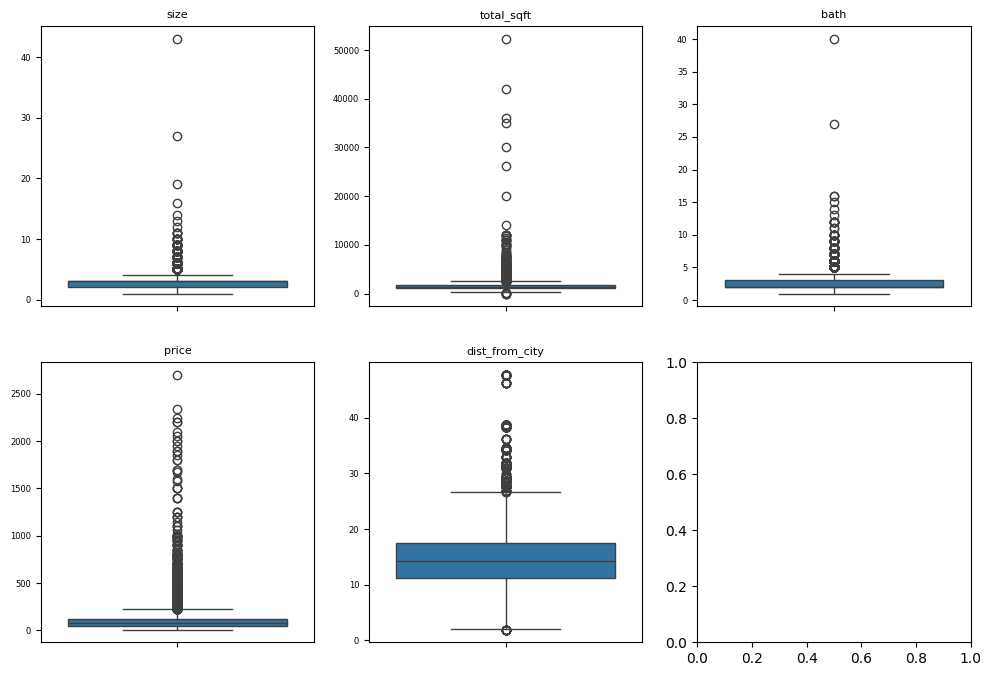

In [141]:
num_df = train_df_copy.select_dtypes(exclude='object')

fig, axes = plt.subplots(2, 3, figsize=(12,8))
axes = axes.flatten()

for i, val in enumerate(num_df.columns):
    ax = axes[i]
    sns.boxplot(num_df[val], ax=ax)
    ax.tick_params(axis='x', labelsize=6) 
    ax.tick_params(axis='y', labelsize=6)
    ax.set_title(val, fontsize=8)
    ax.set_xlabel("")
    ax.set_ylabel("")
plt.show()

In [142]:
train_df_copy['price_per_sqft'] = train_df_copy['price']/train_df_copy['total_sqft']

In [143]:
train_df_copy['price_per_size'] = train_df_copy['price']/train_df_copy['size']

In [144]:
train_df_copy['sqft_per_size'] = train_df_copy['total_sqft']/train_df_copy['size']

In [145]:
train_df_copy['price_per_size'].describe()

count    10641.000000
mean        38.019412
std         35.887374
min          3.333333
25%         21.666667
50%         29.000000
75%         41.250000
max        750.000000
Name: price_per_size, dtype: float64

In [146]:
# Recreate cleaned dataframe and run a quick baseline model with preprocessing + RandomForest
train_df_copy = reuse_func(train_df.copy())

# Select features
features = ['size', 'total_sqft', 'bath', 'balcony', 'area_type', 'location', 'price_per_sqft']
# Ensure features exist
features = [f for f in features if f in train_df_copy.columns]

df_model = train_df_copy.dropna(subset=['log_price'])
X = df_model[features].copy()
y = df_model['log_price']

# Split
from sklearn.model_selection import train_test_split, GridSearchCV
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Preprocessing
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

numeric_features = [c for c in ['size', 'total_sqft', 'bath', 'balcony', 'price_per_sqft'] if c in X.columns]
cat_features = [c for c in ['area_type', 'location'] if c in X.columns]

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse=False))
])
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', cat_transformer, cat_features)
])

pipe = Pipeline(steps=[('pre', preprocessor), ('rf', RandomForestRegressor(random_state=42))])
param_grid = {
    'rf__n_estimators': [50, 100],
    'rf__max_depth': [10, 20, None]
}

search = GridSearchCV(pipe, param_grid, cv=3, scoring='neg_root_mean_squared_error', n_jobs=-1)
search.fit(X_train, y_train)

best = search.best_estimator_
print('Best params:', search.best_params_)

pred_log = best.predict(X_test)
rmse_log = mean_squared_error(y_test, pred_log, squared=False)
# convert back to price space to report RMSE in original units
rmse_price = mean_squared_error(np.expm1(y_test), np.expm1(pred_log), squared=False)
print(f"RMSE (log space): {rmse_log:.4f}")
print(f"RMSE (price): {rmse_price:.2f}")

# Feature importance (approx) for the RF - after preprocessing we can't easily map OHE features back here; we'll show importances from the RF on preprocessed features
try:
    importances = best.named_steps['rf'].feature_importances_
    print('Feature importances (vectorized pipeline):', importances[:10])
except Exception:
    pass

TypeError: OneHotEncoder.__init__() got an unexpected keyword argument 'sparse'

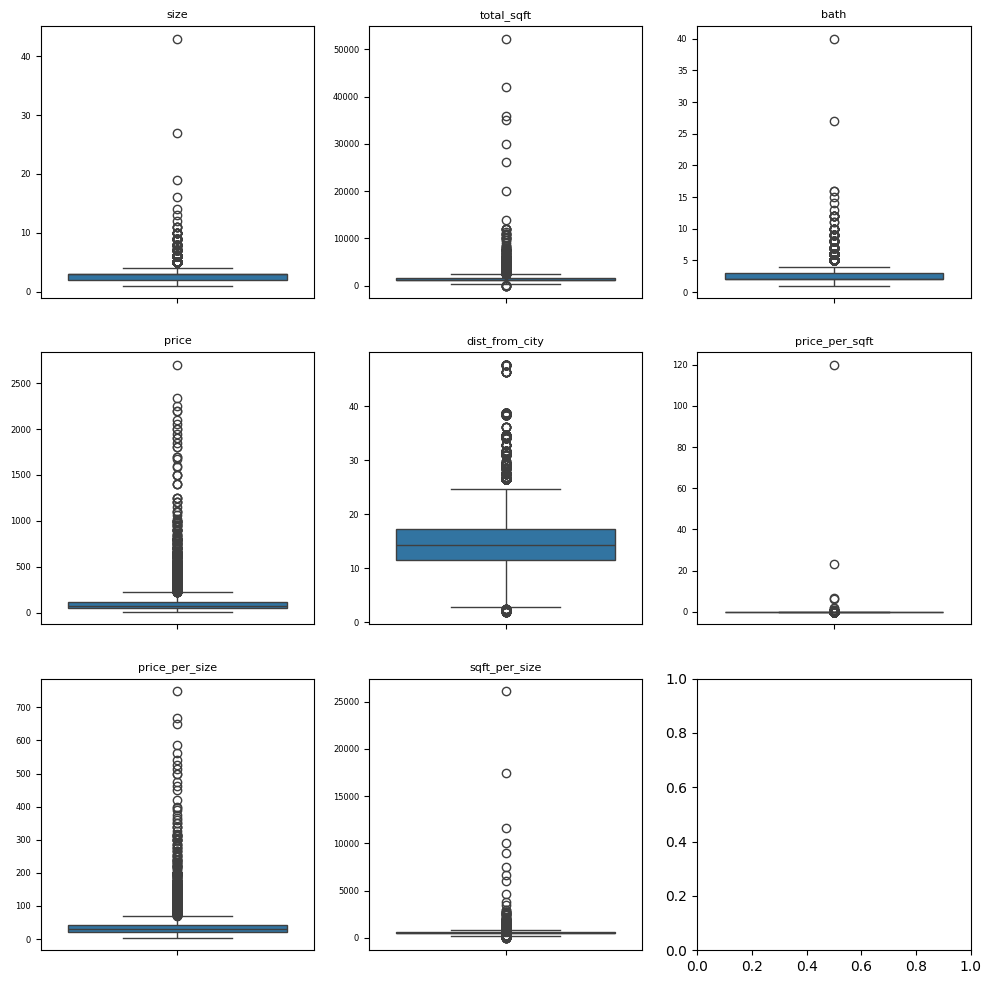

In [ ]:
num_df = train_df_copy.select_dtypes(exclude='object')

fig, axes = plt.subplots(3, 3, figsize=(12,12))
axes = axes.flatten()

for i, val in enumerate(num_df.columns):
    ax = axes[i]
    sns.boxplot(num_df[val], ax=ax)
    ax.tick_params(axis='x', labelsize=6) 
    ax.tick_params(axis='y', labelsize=6)
    ax.set_title(val, fontsize=8)
    ax.set_xlabel("")
    ax.set_ylabel("")
plt.show()

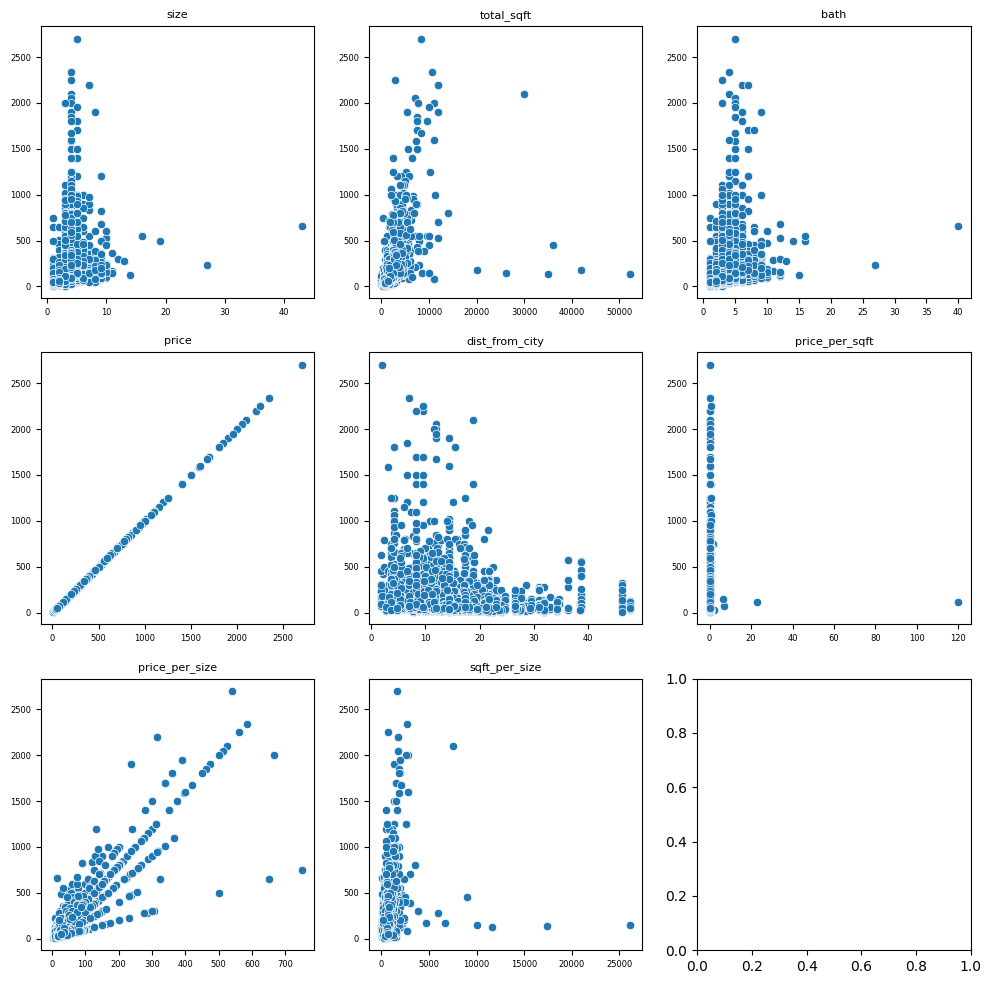

In [ ]:
num_df = train_df_copy.select_dtypes(exclude='object')

fig, axes = plt.subplots(3, 3, figsize=(12,12))
axes = axes.flatten()

for i, val in enumerate(num_df.columns):
    ax = axes[i]
    sns.scatterplot(x=num_df[val], y=num_df['price'], ax=ax)
    ax.tick_params(axis='x', labelsize=6) 
    ax.tick_params(axis='y', labelsize=6)
    ax.set_title(val, fontsize=8)
    ax.set_xlabel("")
    ax.set_ylabel("")
plt.show()

In [ ]:
train_df_copy.columns

Index(['area_type', 'location', 'size', 'total_sqft', 'bath', 'price',
       'dist_from_city', 'price_per_sqft', 'price_per_size', 'sqft_per_size'],
      dtype='object')

In [ ]:
train_df_copy['total_sqft'].describe()

count    10655.000000
mean      1556.036753
std       1274.384177
min          1.000000
25%       1100.000000
50%       1272.000000
75%       1678.000000
max      52272.000000
Name: total_sqft, dtype: float64

In [ ]:
train_df_copy['size'].value_counts()

size
2.0     4427
3.0     3870
4.0     1137
1.0      523
5.0      282
6.0      175
7.0       77
8.0       68
9.0       48
0.0       13
10.0      10
11.0       4
27.0       1
19.0       1
16.0       1
43.0       1
14.0       1
12.0       1
13.0       1
Name: count, dtype: int64

In [ ]:
train_df_copy = train_df_copy[train_df_copy['size']<9]

In [ ]:
train_df_copy.shape

(10572, 8)

In [ ]:
train_df_copy['size'].value_counts()

size
2.0    4427
3.0    3870
4.0    1137
1.0     523
5.0     282
6.0     175
7.0      77
8.0      68
0.0      13
Name: count, dtype: int64

In [ ]:
train_df_copy = train_df_copy[train_df_copy['bath'] < train_df_copy['size']+2]

In [ ]:
low_sz

NameError: name 'low_sz' is not defined

In [ ]:
train_df_copy['price_per_size'].mean() - train_df_copy['price_per_size'].std()

2.825921798729212

In [ ]:
low_sqft = train_df_copy['price_per_sqft'].quantile(0.005)
train_df_copy = train_df_copy[train_df_copy['price_per_sqft'] > low_sqft]

In [ ]:
low_sqft_sz = train_df_copy['sqft_per_size'].quantile(0.005)
train_df_copy = train_df_copy[train_df_copy['sqft_per_size'] > low_sqft_sz]

In [ ]:
high_sqft = train_df_copy['price_per_sqft'].quantile(0.995)
train_df_copy = train_df_copy[train_df_copy['price_per_sqft'] < high_sqft]

In [ ]:
high_sz = train_df_copy['price_per_size'].quantile(0.995)
train_df_copy = train_df_copy[train_df_copy['price_per_size'] < high_sz]

In [ ]:
high_sqft_sz = train_df_copy['sqft_per_size'].quantile(0.995)
train_df_copy = train_df_copy[train_df_copy['sqft_per_size'] < high_sqft_sz]

In [ ]:
train_df_copy.shape

(10130, 10)

In [ ]:
train_df_copy.columns

Index(['area_type', 'location', 'size', 'total_sqft', 'bath', 'price',
       'dist_from_city', 'price_per_sqft', 'price_per_size', 'sqft_per_size'],
      dtype='object')

In [ ]:
train_df_copy.drop(columns=['price_per_sqft', 'price_per_size', 'sqft_per_size'], inplace=True)

In [ ]:
# Robust outlier capping using IQR per numeric column
# This function caps values outside [Q1 - 1.5*IQR, Q3 + 1.5*IQR] to the boundary values
def outliers(x):
    df = x.copy()
    cols = df.select_dtypes(exclude='object').columns
    for col in cols:
        if col == 'price':
            # keep target untouched here; handle target-specific logic elsewhere if needed
            continue
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        minimum = Q1 - IQR*1.5
        maximum = Q3 + IQR*1.5
        df.loc[df[col] < minimum, col] = minimum
        df.loc[df[col] > maximum, col] = maximum
    return df

In [ ]:
train_df_copy = outliers(train_df_copy)

In [ ]:
test_df_copy = outliers(test_df_copy)

In [ ]:
test_df_copy.shape

(2664, 6)

In [ ]:
train_df_copy.shape

(10130, 7)

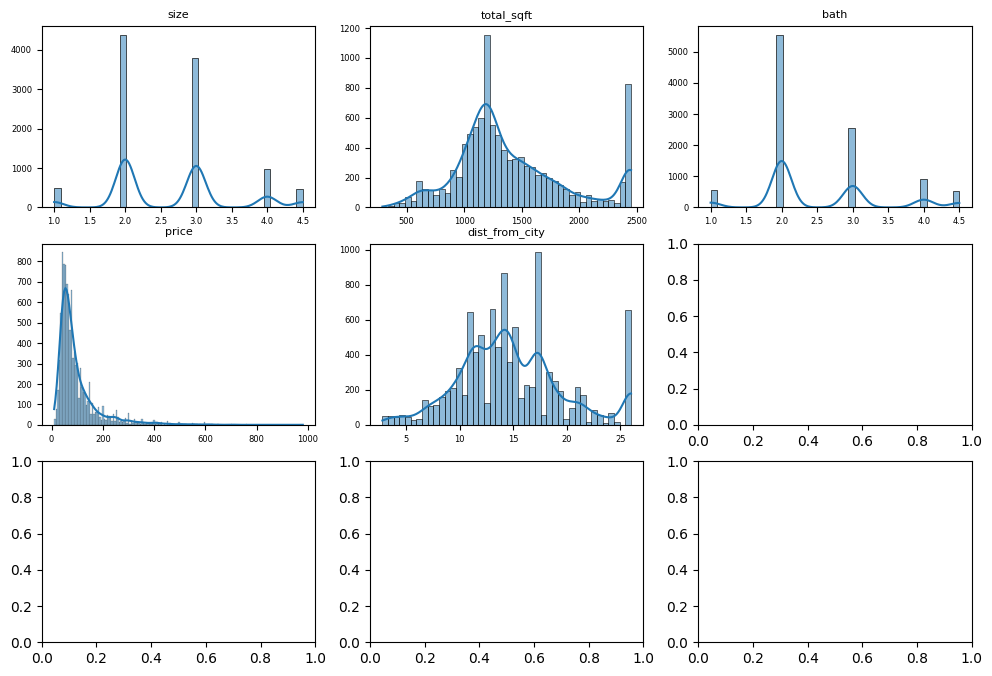

In [ ]:
num_df = train_df_copy.select_dtypes(exclude='object')

fig, axes = plt.subplots(3, 3, figsize=(12,8))
axes = axes.flatten()

for i, val in enumerate(num_df.columns):
    ax = axes[i]
    sns.histplot(x=num_df[val], kde=True, ax=ax)
    ax.tick_params(axis='x', labelsize=6) 
    ax.tick_params(axis='y', labelsize=6)
    ax.set_title(val, fontsize=8)
    ax.set_xlabel("")
    ax.set_ylabel("")
plt.show()

In [ ]:
num_df

,size,total_sqft,bath,price,dist_from_city
0,2.0,1056.000,2.0,39.07,19.3
1,4.0,2449.375,4.5,120.00,26.0
2,3.0,1440.000,2.0,62.00,12.9
3,3.0,1521.000,3.0,95.00,21.4
4,2.0,1200.000,2.0,51.00,11.8
...,...,...,...,...,...
10651,1.0,1200.000,1.0,45.00,14.6
10652,2.0,1260.000,2.0,69.90,15.3
10653,2.0,1092.000,2.0,49.00,13.4
10654,2.0,827.000,2.0,34.00,14.3


In [ ]:
test_df_copy.shape

(2664, 6)

In [ ]:
tst_ans = pd.read_csv('Datasets/bengaluru_house_prices.csv')

In [ ]:
tst_ans.columns

Index(['area_type', 'availability', 'location', 'size', 'society',
       'total_sqft', 'bath', 'balcony', 'price'],
      dtype='object')

In [ ]:
tst_ans.iloc[10656:].drop(columns=['area_type', 'availability', 'location', 'size', 'society','total_sqft', 'bath', 'balcony',]).shape

(2664, 1)

In [ ]:
test_df_copy.select_dtypes(exclude='object').shape

(2664, 4)

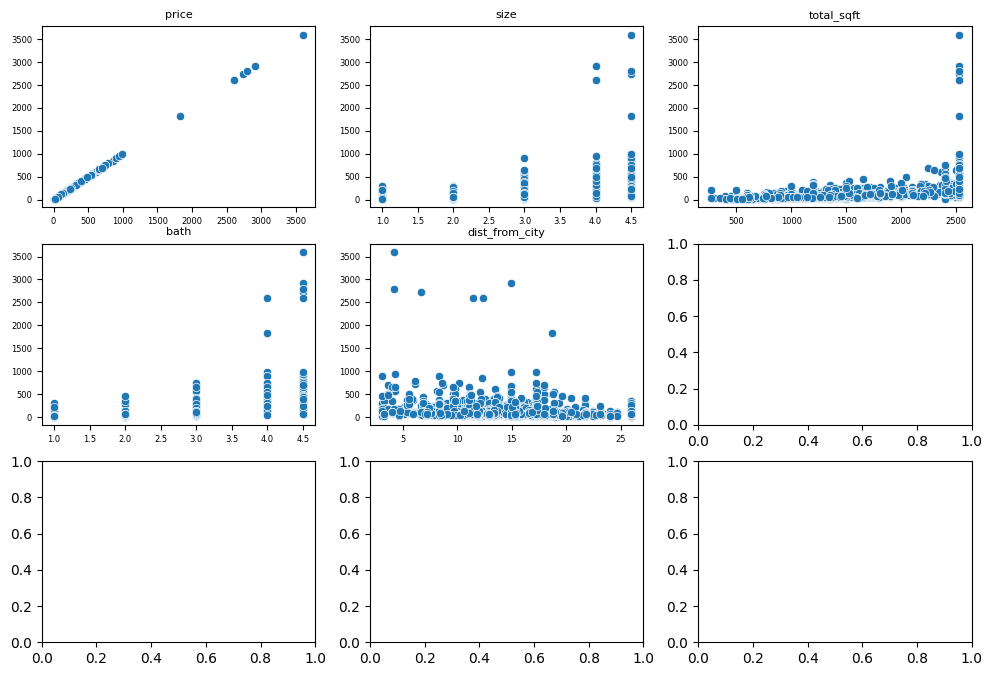

In [ ]:
df1 = tst_ans.iloc[10656:].drop(columns=['area_type', 'availability', 'location', 'size', 'society','total_sqft', 'bath', 'balcony']).reset_index(drop=True)
df2 = test_df_copy.select_dtypes(exclude='object').reset_index(drop=True)

num_df = pd.concat([df1, df2], axis=1)

fig, axes = plt.subplots(3, 3, figsize=(12,8))
axes = axes.flatten()

for i, val in enumerate(num_df.columns):
    ax = axes[i]
    sns.scatterplot(x=num_df[val], y=num_df['price'], ax=ax)
    ax.tick_params(axis='x', labelsize=6) 
    ax.tick_params(axis='y', labelsize=6)
    ax.set_title(val, fontsize=8)
    ax.set_xlabel("")
    ax.set_ylabel("")
plt.show()

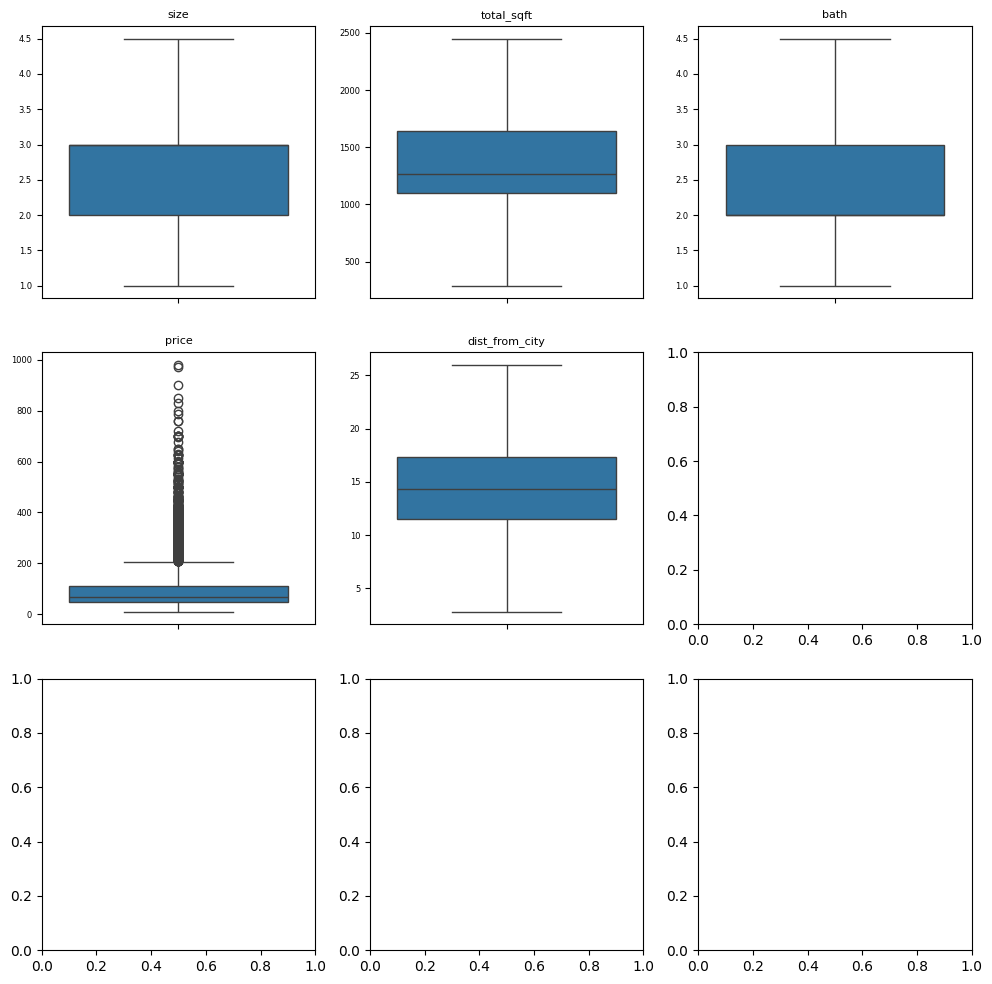

In [ ]:
num_df = train_df_copy.select_dtypes(exclude='object')

fig, axes = plt.subplots(3, 3, figsize=(12,12))
axes = axes.flatten()

for i, val in enumerate(num_df.columns):
    ax = axes[i]
    sns.boxplot(num_df[val], ax=ax)
    ax.tick_params(axis='x', labelsize=6) 
    ax.tick_params(axis='y', labelsize=6)
    ax.set_title(val, fontsize=8)
    ax.set_xlabel("")
    ax.set_ylabel("")
plt.show()

In [ ]:
train_df_copy.price.max()

980.0

In [ ]:
train_df.price.max()

2700.0

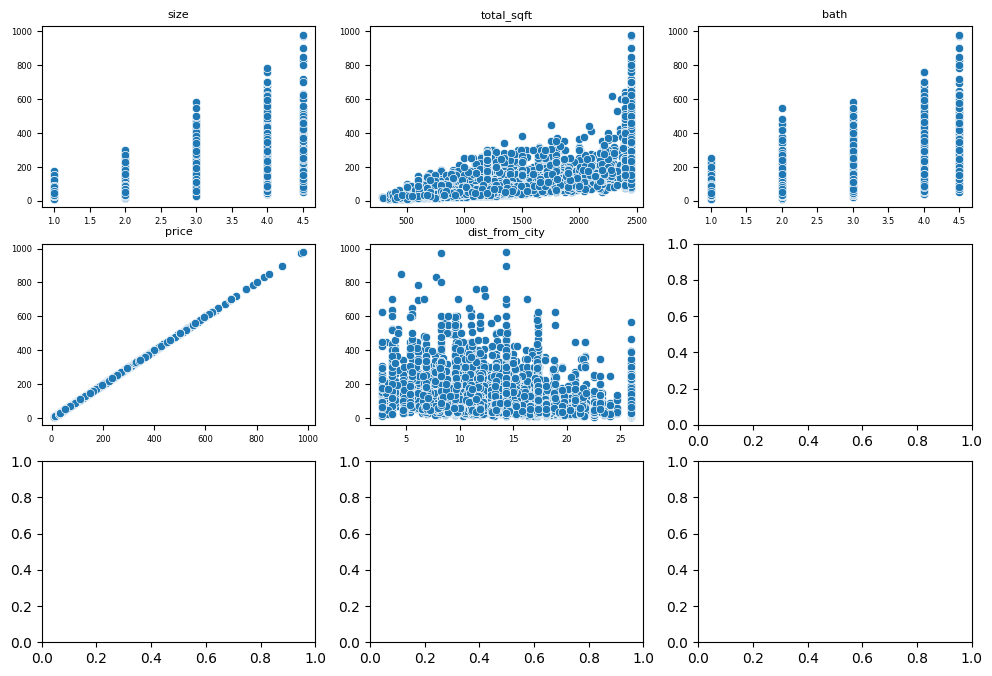

In [ ]:
num_df = train_df_copy.select_dtypes(exclude='object')

fig, axes = plt.subplots(3, 3, figsize=(12,8))
axes = axes.flatten()

for i, val in enumerate(num_df.columns):
    ax = axes[i]
    sns.scatterplot(x=num_df[val], y=num_df['price'], ax=ax)
    ax.tick_params(axis='x', labelsize=6) 
    ax.tick_params(axis='y', labelsize=6)
    ax.set_title(val, fontsize=8)
    ax.set_xlabel("")
    ax.set_ylabel("")
plt.show()

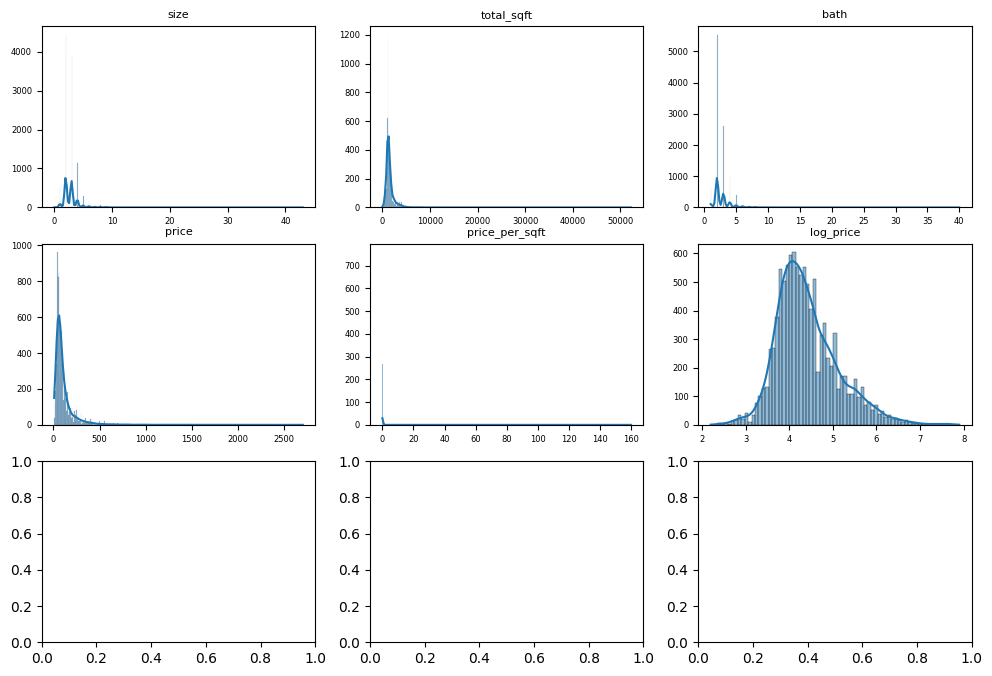

In [147]:
num_df = train_df_copy.select_dtypes(exclude='object')

fig, axes = plt.subplots(3, 3, figsize=(12,8))
axes = axes.flatten()

for i, val in enumerate(num_df.columns):
    ax = axes[i]
    sns.histplot(x=num_df[val], kde=True, ax=ax)
    ax.tick_params(axis='x', labelsize=6) 
    ax.tick_params(axis='y', labelsize=6)
    ax.set_title(val, fontsize=8)
    ax.set_xlabel("")
    ax.set_ylabel("")
plt.show()

In [148]:
corr = train_df_copy.corr(numeric_only=True)

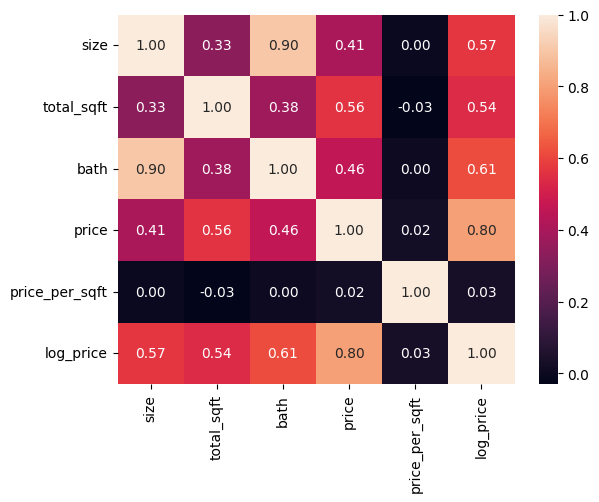

In [149]:
sns.heatmap(corr, annot=True, fmt='0.2f')
plt.show()

**Removed debug cell** — this cell previously displayed the DataFrame during exploration and was converted to a note to keep the notebook tidy.

**Removed debug cell** — duplicate display removed to reduce noise.

In [150]:
train_df_copy.columns

Index(['area_type', 'location', 'size', 'total_sqft', 'bath', 'price',
       'price_per_sqft', 'log_price'],
      dtype='object')

In [151]:
train_df_copy.select_dtypes(exclude='number')

,area_type,location
0,Super built-up Area,Electronic City Phase II
1,Plot Area,Chikka Tirupathi
2,Built-up Area,Uttarahalli
3,Super built-up Area,Lingadheeranahalli
4,Super built-up Area,Kothanur
...,...,...
10651,Plot Area,Parappana Agrahara
10652,Super built-up Area,Bhoganhalli
10653,Super built-up Area,Sector 2 HSR Layout
10654,Super built-up Area,Other


In [153]:
# Scaling numeric features and one-hot encoding categorical features
# Note: this is a quick encoder used for downstream linear models; pipelines are recommended for production
def scalar_encoder(x):
    df = x.copy()
    scale_col = ['size','bath','total_sqft', 'dist_from_city']
    # Optionally log-transform highly skewed numeric columns before scaling
    # log_transform = ['total_sqft', 'dist_from_city', 'sqft_per_size']
    # df[log_transform] = np.log1p(df[log_transform])

    scalar = StandardScaler()
    df[scale_col] = scalar.fit_transform(df[scale_col])

    # One-hot encode location & area_type and drop original columns
    df = pd.concat((df, pd.get_dummies(df[['location','area_type']], sparse=False, dtype='int')), axis=1)
    # drop the original categorical columns and unwanted dummy columns if present
    df.drop(columns=[c for c in ['location', 'area_type', 'location_Other', 'area_type_Super built-up  Area'] if c in df.columns], inplace=True)

    return df

In [154]:
train_df_copy = scalar_encoder(train_df_copy)

KeyError: "['dist_from_city'] not in index"

In [155]:
test_df_copy = scalar_encoder(test_df_copy)

NameError: name 'test_df_copy' is not defined

In [156]:
missing_cols = set(train_df_copy.columns) - set(test_df_copy.columns)
for col in missing_cols:
    test_df_copy[col] = 0

# Ensure same column order
test_df_copy = test_df_copy[train_df_copy.columns]

NameError: name 'test_df_copy' is not defined

In [157]:
test_df_copy

NameError: name 'test_df_copy' is not defined

In [158]:
train_df_copy

,area_type,location,size,total_sqft,bath,price,price_per_sqft,log_price
0,Super built-up Area,Electronic City Phase II,2.0,1056.0,2.0,39.07,0.036998,3.690628
1,Plot Area,Chikka Tirupathi,4.0,2600.0,5.0,120.00,0.046154,4.795791
2,Built-up Area,Uttarahalli,3.0,1440.0,2.0,62.00,0.043056,4.143135
3,Super built-up Area,Lingadheeranahalli,3.0,1521.0,3.0,95.00,0.062459,4.564348
4,Super built-up Area,Kothanur,2.0,1200.0,2.0,51.00,0.042500,3.951244
...,...,...,...,...,...,...,...,...
10651,Plot Area,Parappana Agrahara,1.0,1200.0,1.0,45.00,0.037500,3.828641
10652,Super built-up Area,Bhoganhalli,2.0,1260.0,2.0,69.90,0.055476,4.261270
10653,Super built-up Area,Sector 2 HSR Layout,2.0,1092.0,2.0,49.00,0.044872,3.912023
10654,Super built-up Area,Other,2.0,827.0,2.0,34.00,0.041112,3.555348


In [159]:
train_df_copy.drop(columns=['price'])

,area_type,location,size,total_sqft,bath,price_per_sqft,log_price
0,Super built-up Area,Electronic City Phase II,2.0,1056.0,2.0,0.036998,3.690628
1,Plot Area,Chikka Tirupathi,4.0,2600.0,5.0,0.046154,4.795791
2,Built-up Area,Uttarahalli,3.0,1440.0,2.0,0.043056,4.143135
3,Super built-up Area,Lingadheeranahalli,3.0,1521.0,3.0,0.062459,4.564348
4,Super built-up Area,Kothanur,2.0,1200.0,2.0,0.042500,3.951244
...,...,...,...,...,...,...,...
10651,Plot Area,Parappana Agrahara,1.0,1200.0,1.0,0.037500,3.828641
10652,Super built-up Area,Bhoganhalli,2.0,1260.0,2.0,0.055476,4.261270
10653,Super built-up Area,Sector 2 HSR Layout,2.0,1092.0,2.0,0.044872,3.912023
10654,Super built-up Area,Other,2.0,827.0,2.0,0.041112,3.555348


In [160]:
X = train_df_copy.drop(columns=['price'])
y = np.log1p(train_df_copy['price'])
train_x, test_x, train_y, test_y = train_test_split(X, y, train_size=0.8, random_state=42)

In [161]:
print(train_x.shape, test_x.shape, train_y.shape, test_y.shape)

(8524, 7) (2131, 7) (8524,) (2131,)


In [162]:
lin_model = LinearRegression()
lin_model.fit(train_x,train_y)


ValueError: could not convert string to float: 'Super built-up  Area'

In [163]:
lin_model.score(train_x, train_y)

ValueError: could not convert string to float: 'Super built-up  Area'

In [164]:
lin_model.score(test_x, test_y)

ValueError: could not convert string to float: 'Super built-up  Area'

In [165]:
lin_model.predict(test_df_copy.drop(columns='price'))

NameError: name 'test_df_copy' is not defined

In [166]:
prc = np.log1p(tst_ans.iloc[10656:]['price'])

NameError: name 'tst_ans' is not defined

In [167]:
prc

NameError: name 'prc' is not defined

In [168]:
test_df_copy

NameError: name 'test_df_copy' is not defined

In [169]:
lin_model.score(test_df_copy.drop(columns='price'), prc)

NameError: name 'test_df_copy' is not defined

In [170]:
from sklearn.model_selection import ShuffleSplit
from sklearn.model_selection import cross_val_score

cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=0) # ShuffleSplit - Randomize the sample

cross_val_score(LinearRegression(), X, y, cv=cv)

ValueError: 
All the 5 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_base.py", line 601, in fit
    X, y = validate_data(
           ^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py", line 2961, in validate_data
    X, y = check_X_y(X,

In [ ]:
features_combined_train_const = sm.add_constant(train_x)
model = sm.OLS(train_y, features_combined_train_const).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.788
Model:                            OLS   Adj. R-squared:                  0.784
Method:                 Least Squares   F-statistic:                     231.3
Date:                Mon, 03 Nov 2025   Prob (F-statistic):               0.00
Time:                        17:56:01   Log-Likelihood:                -1662.3
No. Observations:                8104   AIC:                             3583.
Df Residuals:                    7975   BIC:                             4486.
Df Model:                         128                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
const 

In [171]:
y_pred = model.predict(features_combined_train_const)
residuals = model.resid
plt.figure(figsize=(12,5))

# 1. Residual Plot
plt.subplot(1, 2, 1)
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(y=0, linestyle='--')
plt.title("Residuals vs Fitted Values")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

# 2. Q-Q Plot
plt.subplot(1, 2, 2)
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals")

plt.tight_layout()
plt.show()

NameError: name 'model' is not defined

In [172]:
features_to_keep = train_x.columns.to_list()
while True:
    model = sm.OLS(train_y, sm.add_constant(train_x[features_to_keep])).fit()
    p_values = model.pvalues.drop('const')
    max_p_value = p_values.max()

    if max_p_value > 0.05:
        # Remove the least significant feature
        feature_to_remove = p_values.idxmax()
        features_to_keep.remove(feature_to_remove)
    else:
        # Stop when all remaining features are significant
        break
print(features_to_keep)

ValueError: Pandas data cast to numpy dtype of object. Check input data with np.asarray(data).

In [173]:
len(features_to_keep)

7

In [174]:
features_combined_train_const = sm.add_constant(train_x[features_to_keep])
model = sm.OLS(train_y, features_combined_train_const).fit()
print(model.summary())

ValueError: Pandas data cast to numpy dtype of object. Check input data with np.asarray(data).

In [175]:
y_pred = model.predict(features_combined_train_const)
residuals = model.resid
plt.figure(figsize=(12,5))

# 1. Residual Plot
plt.subplot(1, 2, 1)
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(y=0, linestyle='--')
plt.title("Residuals vs Fitted Values")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

# 2. Q-Q Plot
plt.subplot(1, 2, 2)
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals")

plt.tight_layout()
plt.show()

NameError: name 'model' is not defined

In [176]:
model = LinearRegression()
model.fit(train_x[features_to_keep],train_y)

ValueError: could not convert string to float: 'Super built-up  Area'

In [177]:
model.score(test_x[features_to_keep], test_y)

ValueError: could not convert string to float: 'Super built-up  Area'

In [178]:
model.predict(train_x[features_to_keep])

ValueError: could not convert string to float: 'Super built-up  Area'

In [179]:
model.score(test_df_copy[features_to_keep], prc)

NameError: name 'test_df_copy' is not defined

In [180]:
def calculate_vif(df):
    vif_data = pd.DataFrame()
    vif_data["feature"] = df.columns
    vif_values = []

    for col in df.columns:
        X = df.drop(columns=[col])
        y = df[col]

        model = LinearRegression().fit(X, y)
        r2 = model.score(X, y)
        vif = 1 / (1 - r2)
        vif_values.append(vif)

    vif_data["VIF"] = vif_values
    return vif_data

In [181]:
vif_table = calculate_vif(train_x)
print(vif_table)

ValueError: could not convert string to float: 'Yelahanka'

In [182]:
vif_table[vif_table['VIF'] > 5]['feature'].to_list()

NameError: name 'vif_table' is not defined

In [183]:
col_to_ex = list(set(train_x.columns.to_list()) - set(vif_table[vif_table['VIF'] > 10]['feature'].to_list()))

NameError: name 'vif_table' is not defined

In [184]:
features_combined_train_const = sm.add_constant(train_x[col_to_ex])
model = sm.OLS(train_y, features_combined_train_const).fit()
print(model.summary())

NameError: name 'col_to_ex' is not defined

In [185]:
def find_best_model_using_gridsearchCV(x,y):
    algos = {
        'linear_regression' : {
            'model' : LinearRegression(),
            'params' : {
                # 'normalize' : [True, False]
            }
        },
        'lasso' : {
            'model' : Lasso(max_iter=10000),
            'params' : {
                "alpha": [0.0001, 0.001, 0.01, 0.05, 0.1, 0.5, 1, 2, 5, 10],
                "fit_intercept": [True, False],
                "selection": ["cyclic", "random"]
            }
        },
        'ridge' : {
            'model' : Ridge(),
            'params' : {
                "alpha": [0.0001, 0.001, 0.01, 0.1, 1, 5, 10, 20, 50, 100, 200, 500, 1000],
                "fit_intercept": [True, False],
                "solver": ["auto", "svd", "cholesky", "lsqr", "sag", "saga", "lbfgs"]
            }
        }
    }

    scores = []
    cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=0)
    for algo_name, config in algos.items():
        gs = GridSearchCV(config['model'], config['params'], cv=cv, return_train_score=False)
        gs.fit(x,y)
        scores.append({
            'model' : algo_name,
            'best_score' : gs.best_score_,
            'best_params' : gs.best_params_
        })

    return pd.DataFrame(scores, columns=['model', 'best_score', 'best_params'])

In [186]:
params = {
    "alpha": [0.01, 0.1, 1, 2, 3, 5, 10, 100, 500, 1000],
    "fit_intercept": [True, False],
    "solver": ["auto", "svd", "cholesky", "sag", "saga", "lbfgs"]
}